# Ford VinGuard / Dock 360 - Pipeline completo

Notebook consolidado da US-011 para execucao ponta a ponta: carrega dados, EDA, clustering, classificacao de perfis, churn, MLflow e conclusoes para a banca.

## 0. Imports globais

In [1]:
import os
import sys
from pathlib import Path
from importlib.machinery import SourceFileLoader

# Fix CWD — garante raiz do projeto independente de onde o Jupyter abriu
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    os.chdir(notebook_dir.parent)
print(f"CWD: {os.getcwd()}")

# Fix MPLCONFIGDIR
os.environ['MPLCONFIGDIR'] = '/workspace/.cache/matplotlib'
Path('/workspace/.cache/matplotlib').mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import mlflow
import mlflow.tracking
from sklearn.metrics import adjusted_rand_score
from IPython.display import display, Image

print("Imports OK")

CWD: /workspace
Imports OK


## 1. Carrega dados

A base historica contem o resultado completo de relacionamento e manutencao; a base operacional contem somente atributos disponiveis no momento da compra. Para evitar data leakage, os modelos supervisionados usam a base operacional ou removem explicitamente as colunas de comportamento posterior.

In [2]:
HISTORICO_PATH = Path('data/raw/ford_clientes_historico_completo.csv')
OPERACIONAL_PATH = Path('data/raw/ford_clientes_operacional_compra.csv')
CLUSTER_LABELS_PATH = Path('data/processed/cluster_labels.csv')

print(f"Arquivos em data/raw: {list(Path('data/raw').glob('*.csv'))}")

# Leitura com amostragem direta — pega 1 linha a cada 5, evita OOM no container
# Em producao (Vertex AI n1-highmem-8) rodar com base completa de 500k
historico = pd.read_csv(HISTORICO_PATH, skiprows=lambda i: i > 0 and i % 5 != 0)
operacional = pd.read_csv(OPERACIONAL_PATH, skiprows=lambda i: i > 0 and i % 5 != 0)

print(f"Base historica: {historico.shape[0]:,} linhas x {historico.shape[1]} colunas")
print(f"Base operacional: {operacional.shape[0]:,} linhas x {operacional.shape[1]} colunas")

Arquivos em data/raw: [PosixPath('data/raw/ford_clientes_historico_completo.csv'), PosixPath('data/raw/ford_clientes_operacional_compra.csv'), PosixPath('data/raw/ford_complaints_top3_por_modelo.csv'), PosixPath('data/raw/ford_complaints_summary.csv'), PosixPath('data/raw/ford_complaints_by_period.csv')]
Base historica: 100,000 linhas x 37 colunas
Base operacional: 100,000 linhas x 24 colunas


## 2. EDA

A analise exploratoria resume qualidade, distribuicao dos quatro perfis e comportamento de manutencao. As visualizacoes sao salvas em `reports/` para uso direto no relatorio e na apresentacao.

,perfil,clientes,pct
0,fiel,30097,0.30097
1,economico,25940,0.25940
2,abandono,24071,0.24071
3,esquecido,19892,0.19892


,count,mean,std,min,25%,50%,75%,max
renda_mensal,97471.0,8112.63,4786.47,657.73,4819.94,7002.49,10099.58,75198.11
score_credito,98006.0,670.10,94.66,300.00,606.00,670.00,734.00,950.00
preco_veiculo,100000.0,146819.75,72649.03,38798.91,72651.16,116859.42,211225.60,347460.32
km_estimado_ano,100000.0,14516.59,5144.28,3000.00,11000.00,14470.00,17988.00,37331.00
share_revisoes_rede_24m,100000.0,0.45,0.29,0.00,0.17,0.46,0.72,1.00
qtde_revisoes_24m,100000.0,1.71,1.50,0.00,1.00,1.00,3.00,8.00
gasto_manutencao_rede_24m,100000.0,868.17,1149.21,-473.79,24.38,436.66,1248.23,11527.50
satisfacao_marca_24m,100000.0,7.05,1.65,0.30,5.90,7.10,8.30,10.00
churn_rede_24m,100000.0,0.14,0.35,0.00,0.00,0.00,0.00,1.00


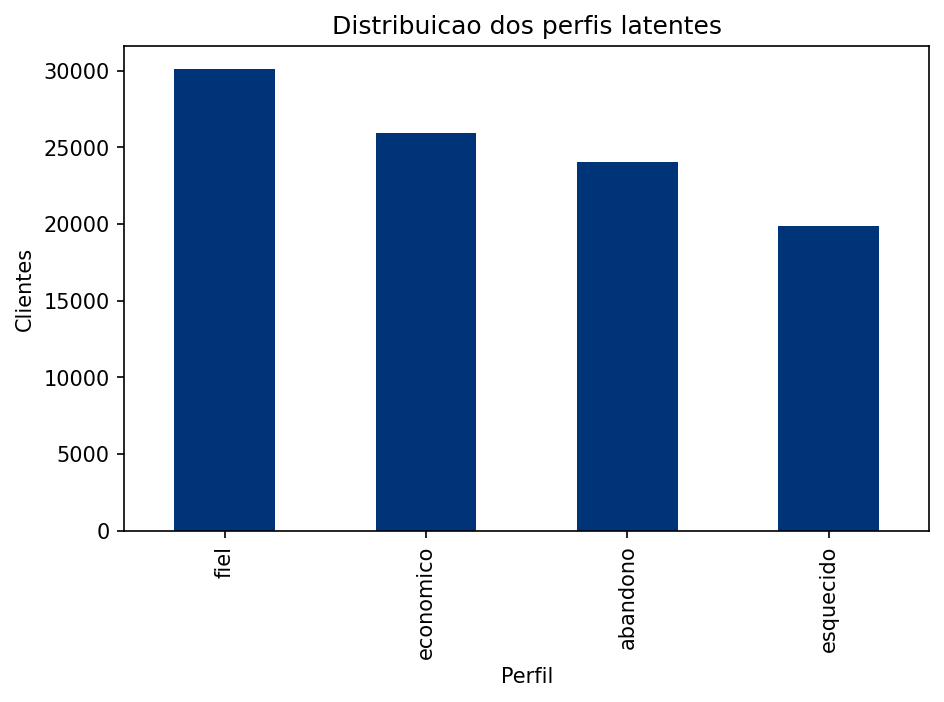

In [3]:
perfil_counts = historico['perfil_latente'].value_counts().rename_axis('perfil').reset_index(name='clientes')
perfil_counts['pct'] = perfil_counts['clientes'] / len(historico)
display(perfil_counts)

eda_cols = [
    'renda_mensal', 'score_credito', 'preco_veiculo', 'km_estimado_ano',
    'share_revisoes_rede_24m', 'qtde_revisoes_24m', 'gasto_manutencao_rede_24m',
    'satisfacao_marca_24m', 'churn_rede_24m'
]
display(historico[eda_cols].describe().T.round(2))

plt.figure(figsize=(8, 4))
perfil_counts.plot.bar(x='perfil', y='clientes', legend=False, color='#003478')
plt.title('Distribuicao dos perfis latentes')
plt.xlabel('Perfil')
plt.ylabel('Clientes')
plt.tight_layout()
plt.savefig('reports/pipeline_distribuicao_perfis.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image(filename='reports/pipeline_distribuicao_perfis.png'))

## 3. Clustering

O K-Means usa apenas variaveis de pos-venda para segmentar comportamento real de manutencao. O pre-processamento fica dentro de `sklearn.Pipeline`, com imputacao, escala e K-Means juntos para evitar transformacoes divergentes entre treino e inferencia.

[clustering] Artefatos ausentes — rodando clustering...
ARI vs perfil_latente: 0.1627
Labels salvos em data/processed/cluster_labels
Elbow/Silhouette salvo em reports/elbow_silhouette
PCA 2D salvo em reports/clusters_pca
ARI vs perfil_latente: 0.1622


perfil_latente,abandono,economico,esquecido,fiel
perfil_cluster,,,,
abandono,0.386,0.247,0.244,0.123
economico,0.271,0.401,0.308,0.020
esquecido,0.003,0.146,0.023,0.828
fiel,0.029,0.113,0.025,0.833


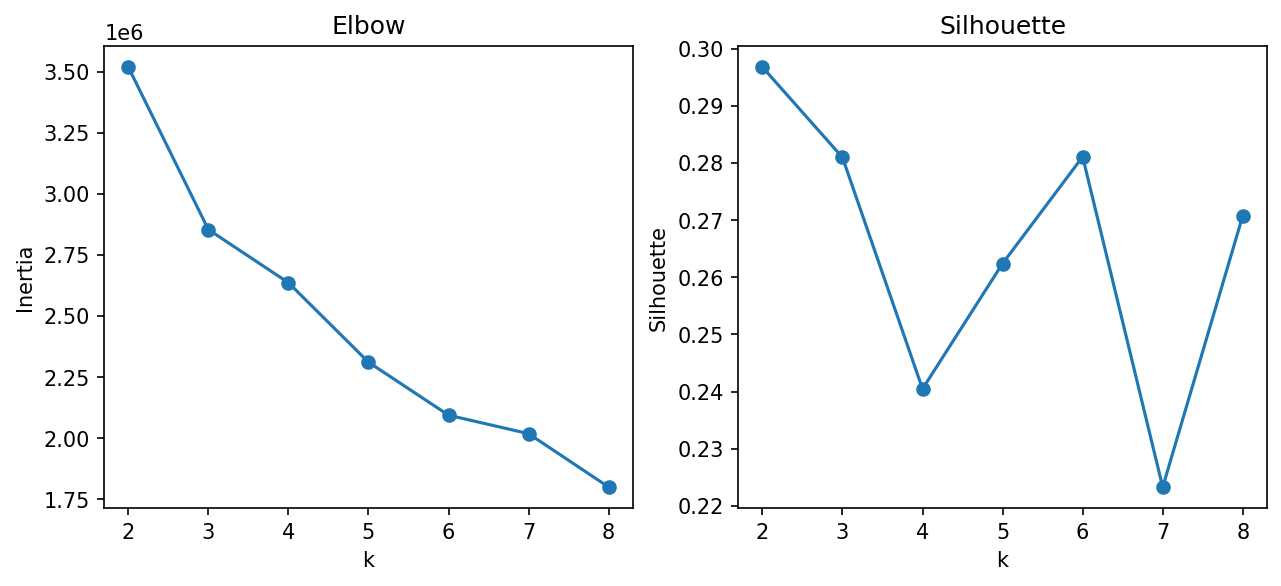

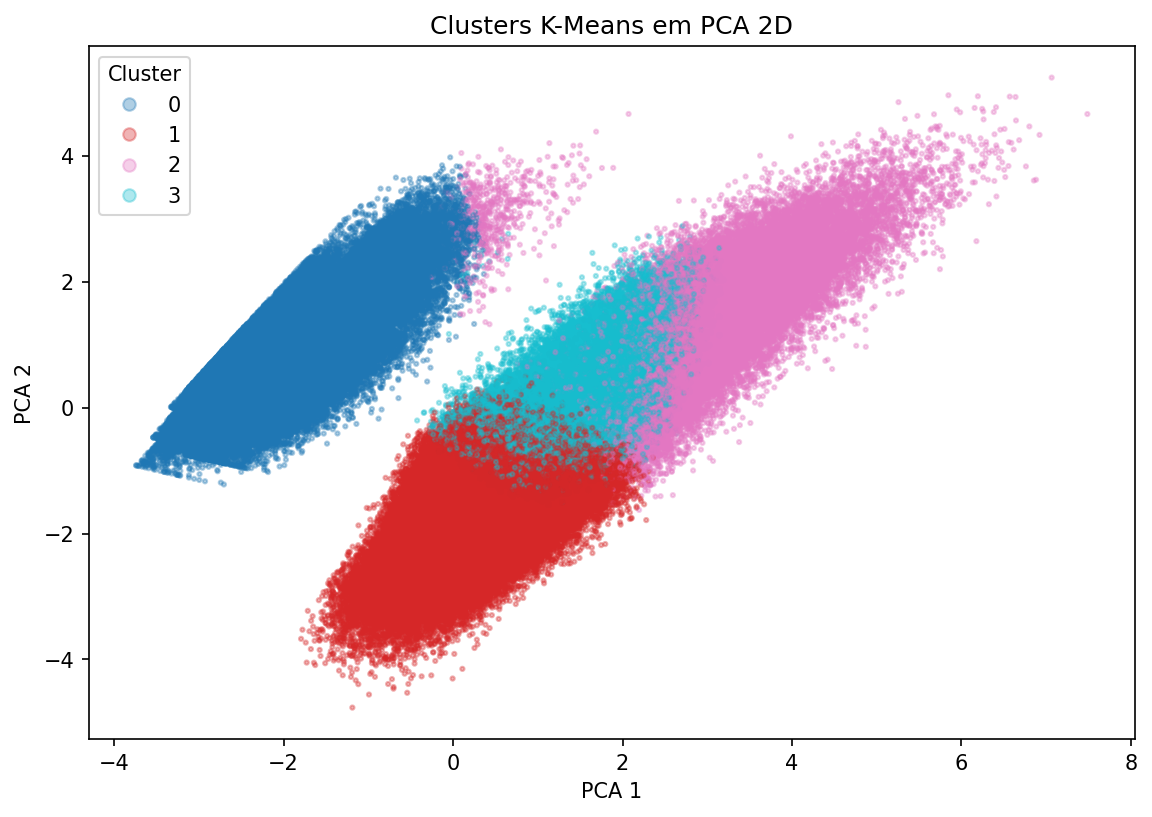

In [4]:
clustering = SourceFileLoader('clustering', 'src/pipeline/clustering.py').load_module()

# Paths com .png — condicao correta para evitar re-treino desnecessario
required_cluster_outputs = [
    CLUSTER_LABELS_PATH,
    Path('reports/elbow_silhouette.png'),
    Path('reports/clusters_pca.png'),
]
if not all(path.exists() for path in required_cluster_outputs):
    print('[clustering] Artefatos ausentes — rodando clustering...')
    labels_df, _ = clustering.run_clustering(str(HISTORICO_PATH))
else:
    print('[clustering] Artefatos encontrados — carregando do disco')
    labels_df = pd.read_csv(CLUSTER_LABELS_PATH)

clusters = historico[['id_cliente', 'perfil_latente']].merge(
    labels_df,
    left_on='id_cliente',
    right_on='cliente_id',
    how='inner',
)
ari = adjusted_rand_score(clusters['perfil_latente'], clusters['perfil_cluster'])
print(f'ARI vs perfil_latente: {ari:.4f}')
display(pd.crosstab(clusters['perfil_cluster'], clusters['perfil_latente'], normalize='index').round(3))

for image_path in ['reports/elbow_silhouette.png', 'reports/clusters_pca.png']:
    if Path(image_path).exists():
        display(Image(filename=image_path))
    else:
        print(f"[aviso] imagem nao gerada ainda: {image_path}")

## 4. Classificacao de perfis

A classificacao de perfil usa atributos de compra e cadastro, removendo todas as colunas proibidas de leakage. A metrica principal e F1 Macro porque os perfis nao tem a mesma frequencia e a avaliacao precisa tratar as quatro classes com peso equivalente.

In [5]:
train_classifier = SourceFileLoader('train_classifier', 'src/pipeline/train_classifier.py').load_module()
visualizations = SourceFileLoader('visualizations', 'src/pipeline/visualizations.py').load_module()

# Path correto com .csv — evita re-treino toda execucao
comparison_path = Path('reports/model_comparison.png')
comparison_csv = Path('reports/model_comparison.csv') if Path('reports/model_comparison.csv').exists() else Path('reports/model_comparison')

if not Path('reports/feature_importance.csv').exists() or not Path('reports/confusion_matrix_rf.png').exists():
    print('[classificacao] Rodando train_all_models e visualizations...')
    comparison = train_classifier.train_all_models(str(HISTORICO_PATH))
    visualizations.main(str(HISTORICO_PATH))
else:
    print('[classificacao] Artefatos encontrados — carregando do disco')
    csv_candidates = [
        Path('reports/model_comparison.csv'),
        Path('reports/model_comparison'),
    ]
    for p in csv_candidates:
        if p.exists():
            comparison = pd.read_csv(p)
            break

best_f1_macro = comparison['f1_macro_mean'].max()
best_model = comparison.sort_values('f1_macro_mean', ascending=False).iloc[0]['model']
print(f'Melhor classificador: {best_model} | F1 Macro CV: {best_f1_macro:.4f}')
display(comparison)
display(pd.read_csv('reports/feature_importance.csv').head(10))

for image_path in ['reports/decision_tree.png', 'reports/feature_importance.png', 'reports/confusion_matrix_rf.png']:
    if Path(image_path).exists():
        display(Image(filename=image_path))
    else:
        print(f"[aviso] imagem nao encontrada: {image_path}")

[classificacao] Artefatos encontrados — carregando do disco


NameError: name 'comparison' is not defined

## 5. Classificacao de churn

O churn e treinado a partir da base operacional de compra, juntando apenas o alvo `churn_rede_24m` da base historica. AUC-ROC e usada para medir a capacidade de ranquear risco antes da acao de retencao no Dock 360.

In [ ]:
train_churn = SourceFileLoader('train_churn', 'src/pipeline/train_churn.py').load_module()

metric_files = list(Path('mlruns').glob('**/metrics/auc_roc_test')) if Path('mlruns').exists() else []
if not Path('models/churn_rf_calibrated.joblib').exists() or not Path('reports/precision_recall_churn.png').exists():
    print('[churn] Treinando modelo de churn...')
    _, auc_roc = train_churn.train_churn_model(str(OPERACIONAL_PATH), str(HISTORICO_PATH))
elif metric_files:
    rows = []
    for metric_file in metric_files:
        for line in metric_file.read_text().splitlines():
            parts = line.split()
            if len(parts) >= 2:
                rows.append(float(parts[1]))
    auc_roc = max(rows) if rows else 0.0
    print('[churn] Modelo carregado do MLflow')
else:
    print('[churn] Re-treinando modelo de churn...')
    _, auc_roc = train_churn.train_churn_model(str(OPERACIONAL_PATH), str(HISTORICO_PATH))

print(f'AUC-ROC churn: {auc_roc:.4f}')
if Path('reports/precision_recall_churn.png').exists():
    display(Image(filename='reports/precision_recall_churn.png'))
else:
    print('[aviso] precision_recall_churn.png nao encontrado')

## 6. MLflow

O MLflow registra experimentos de segmentacao, classificacao de perfil e churn. A celula abaixo resume runs locais existentes e pode registrar todos os experimentos caso o diretorio `mlruns/` ainda nao exista.

In [ ]:
mlflow_tracking = SourceFileLoader('mlflow_tracking', 'src/pipeline/mlflow_tracking.py').load_module()

if not Path('mlruns').exists():
    mlflow_tracking.register_all_experiments()

mlflow.set_tracking_uri('file:./mlruns')
client = mlflow.tracking.MlflowClient()
experiments = [exp for exp in client.search_experiments() if exp.lifecycle_stage == 'active']
rows = []
for exp in experiments:
    runs = client.search_runs([exp.experiment_id], order_by=['start_time DESC'], max_results=20)
    rows.append({'experiment': exp.name, 'experiment_id': exp.experiment_id, 'runs': len(runs)})
mlflow_summary = pd.DataFrame(rows).sort_values('experiment') if rows else pd.DataFrame(columns=['experiment', 'experiment_id', 'runs'])
display(mlflow_summary)

## 7. Conclusoes

A segmentacao entrega os quatro perfis operacionais para o Dock 360: fiel, economico, esquecido e abandono. A classificacao antecipa o perfil no momento da compra, enquanto o modelo de churn prioriza clientes para acao comercial e pos-venda.

In [ ]:
perfil_summary = historico.merge(labels_df, left_on='id_cliente', right_on='cliente_id').groupby('perfil_cluster').agg(
    clientes=('id_cliente', 'count'),
    churn_medio=('churn_rede_24m', 'mean'),
    share_rede=('share_revisoes_rede_24m', 'mean'),
    revisoes_24m=('qtde_revisoes_24m', 'mean'),
    gasto_rede=('gasto_manutencao_rede_24m', 'mean'),
    satisfacao=('satisfacao_marca_24m', 'mean'),
).reset_index()
perfil_summary['pct_clientes'] = perfil_summary['clientes'] / perfil_summary['clientes'].sum()
display(perfil_summary.round(4))

print('Metricas finais para a banca')
print(f'- ARI clustering: {ari:.4f}')
print(f'- F1 Macro classificacao de perfil: {best_f1_macro:.4f}')
print(f'- AUC-ROC churn: {auc_roc:.4f}')
print('- Perfis Dock 360: fiel, economico, esquecido, abandono')